# Network Intrusion Detection System: CICIDS-2017 Analysis
> **Project:** Comparative Analysis of Machine Learning Models for Network Attack Classification
> **Dataset:** [CICIDS 2017 (Parquet Format)](https://www.unb.ca/cic/datasets/ids-2017.html)

---

> [!IMPORTANT]
> **Environment & Resource Note:**
> This notebook was originally developed and executed in a **Kaggle Notebook environment**. 
> - **Data Access:** The input paths are set to Kaggle's specific dataset structure (`/kaggle/input/...`).
> - **Model Training:** This notebook contains the experimental flow and results. Running it in a local or different cloud environment will require updating the data paths and ensuring sufficient computational resources (RAM/GPU) for training on 2.3M+ rows.

---

## 1. Introduction
Modern network security relies on the rapid and accurate detection of malicious traffic. This notebook documents a comprehensive experiment using the **CICIDS-2017 dataset** to build and compare multiple machine learning classifiers. Our goal is to develop a robust model capable of distinguishing between benign traffic and various types of network intrusions.

## 2. Dataset Overview
- **Source:** Canadian Institute for Cybersecurity (CIC)
- **Scope:** Includes common network attacks such as DoS, DDoS, PortScan, Brute Force, and more.
- **Key Strategy:**
    - **Label Mapping:** Consolidating 15 granular attack types into 7 major categories for more effective multi-class classification.
    - **Stratified Sampling:** Using 20% of the original dataset to maintain class distribution while improving computational efficiency.
    - **Data Pipeline:** Handling missing/infinite values and applying standard scaling for downstream ML algorithms.

## 3. Experimental Objectives
1. **EDA & Visualization:** Identify patterns and correlations between network flow features and attack types.
2. **Preprocessing:** Build a reusable pipeline for cleaning and transforming raw network traffic data.
3. **Performance Comparison:** Rigorously evaluate models like Random Forest, XGBoost, and others to select the most reliable classifier for real-world IDS deployment.


In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sns

path = "/kaggle/input/datasets/dhoogla/cicids2017"

df_list = []
for f in os.listdir(path):
    if f.endswith(".parquet"):
        temp = pd.read_parquet(os.path.join(path, f))
        print(f"Loaded: {f} | Shape: {temp.shape}")
        df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
print(f"\nTotal shape: {df.shape}")

Loaded: Benign-Monday-no-metadata.parquet | Shape: (458831, 78)
Loaded: Bruteforce-Tuesday-no-metadata.parquet | Shape: (389714, 78)
Loaded: Portscan-Friday-no-metadata.parquet | Shape: (119522, 78)
Loaded: WebAttacks-Thursday-no-metadata.parquet | Shape: (155820, 78)
Loaded: DoS-Wednesday-no-metadata.parquet | Shape: (584991, 78)
Loaded: DDoS-Friday-no-metadata.parquet | Shape: (221264, 78)
Loaded: Infiltration-Thursday-no-metadata.parquet | Shape: (207630, 78)
Loaded: Botnet-Friday-no-metadata.parquet | Shape: (176038, 78)

Total shape: (2313810, 78)


## **Basic EDA**

In [28]:
# Check column names and data types
print(df.dtypes)
print(f"\nTotal columns: {df.shape[1]}")
print(f"Total rows: {df.shape[0]}")

Protocol                       int8
Flow Duration                 int32
Total Fwd Packets             int32
Total Backward Packets        int32
Fwd Packets Length Total      int32
                             ...   
Idle Mean                   float32
Idle Std                    float32
Idle Max                      int32
Idle Min                      int32
Label                        object
Length: 78, dtype: object

Total columns: 78
Total rows: 2313810


In [29]:
# Check missing values
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


In [30]:
# Check infinite values
inf_cols = [col for col in df.select_dtypes(include=[np.number]).columns
            if np.isinf(df[col]).any()]
print(f"Columns with infinite values: {inf_cols}")

Columns with infinite values: []


In [31]:
# Check class distribution
# Label column name may vary - check with df.columns first
df.columns.tolist()

['Protocol',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Fwd Packets Length Total',
 'Bwd Packets Length Total',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Packet Length Min',
 'Packet Length Max',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'URG Flag Count',

In [32]:
# Replace U+FFFD (replacement character) with hyphen
df['Label'] = df['Label'].str.replace('\ufffd', '-', regex=False)

# Check for any other unexpected special characters in labels
print("Unique labels before cleanup:", df['Label'].unique())

# Check class distribution
print("=" * 9 + " Class Distribution " + "=" * 9)
print(df['Label'].value_counts())
print(f"\nTotal classes: {df['Label'].nunique()}" + "\n")

# Check class distribution in percentage
print("=" * 5 + " Distribution in Percentage " + "=" * 5)
print(df['Label'].value_counts(normalize=True).round(4) * 100)

Unique labels before cleanup: ['Benign' 'FTP-Patator' 'SSH-Patator' 'PortScan'
 'Web Attack - Brute Force' 'Web Attack - XSS'
 'Web Attack - Sql Injection' 'DoS slowloris' 'DoS Slowhttptest'
 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed' 'DDoS' 'Infiltration' 'Bot']
========= Class Distribution =========
Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack - Brute Force         1470
Bot                              1437
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Total classes: 15

===== Distribution in Percentage =====
Label
Benign                        85.

In [33]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

Total duplicate rows: 82004


## **Label Mapping (7 Classes)**

In [34]:
# Re-apply the full pipeline from scratch on df_check
df_copy = df.copy()

# Fix encoding
df_copy['Label'] = df_copy['Label'].str.replace('\ufffd', '-', regex=False)

# Define label mapping
label_mapping = {
    'Benign': 'Benign',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'DDoS': 'DDoS',
    'FTP-Patator': 'BruteForce',
    'SSH-Patator': 'BruteForce',
    'PortScan': 'PortScan',
    'Web Attack - Brute Force': 'WebAttack',
    'Web Attack - XSS': 'WebAttack',
    'Web Attack - Sql Injection': 'WebAttack',
    'Bot': 'Botnet',
    'Infiltration': 'DROP',
    'Heartbleed': 'DROP'
}

# Apply mapping
df_copy['Label'] = df_copy['Label'].map(label_mapping)

# Drop rows marked as DROP
df_copy = df_copy[df_copy['Label'] != 'DROP'].reset_index(drop=True)

# Verify
print("=" * 4 + " New Class Distribution " + "=" * 4)
print(df_copy['Label'].value_counts())
print(f"\nTotal classes: {df_copy['Label'].nunique()}")
print(f"Total rows: {df_copy.shape[0]}")

==== New Class Distribution ====
Label
Benign        1977318
DoS            193745
DDoS           128014
BruteForce       9150
WebAttack        2143
PortScan         1956
Botnet           1437
Name: count, dtype: int64

Total classes: 7
Total rows: 2313763


## **Remove Duplicate** 

In [35]:
# Check and remove duplicate rows
print(f"Rows before dropping duplicates: {df_copy.shape[0]}")

df_copy = df_copy.drop_duplicates().reset_index(drop=True)

print(f"Rows after dropping duplicates: {df_copy.shape[0]}")
print(f"Duplicates removed: {2313763 - df_copy.shape[0]}")

Rows before dropping duplicates: 2313763
Rows after dropping duplicates: 2231759
Duplicates removed: 82004


## **Stratified Sampling** 

In [36]:
from sklearn.model_selection import train_test_split

# Sample 20% of the dataset while preserving class distribution
df_sampled, _ = train_test_split(
    df_copy,
    test_size=0.80,
    stratify=df_copy['Label'],
    random_state=42
)

df_sampled = df_sampled.reset_index(drop=True)

# Verify sampling result
print(f"Original shape: {df_copy.shape[0]}")
print(f"Sampled shape: {df_sampled.shape[0]}")
print(f"\n{'=' * 6} Sampled Class Distribution {'=' *  6}")
print(df_sampled['Label'].value_counts())
print(f"\n{'=' * 3} Sampled Distribution in Percentage {'=' * 3}")
print(df_sampled['Label'].value_counts(normalize=True).round(4) * 100)



# Verify stratification preserved class proportions
original_pct = df_copy['Label'].value_counts(normalize=True).round(4)
sampled_pct  = df_sampled['Label'].value_counts(normalize=True).round(4)
print("Proportion drift (should be ~0):")
print((original_pct - sampled_pct).abs().sort_values(ascending=False))

Original shape: 2231759
Sampled shape: 446351

====== Sampled Class Distribution ======
Label
Benign        379062
DoS            38749
DDoS           25603
BruteForce      1830
WebAttack        429
PortScan         391
Botnet           287
Name: count, dtype: int64

=== Sampled Distribution in Percentage ===
Label
Benign        84.92
DoS            8.68
DDoS           5.74
BruteForce     0.41
WebAttack      0.10
PortScan       0.09
Botnet         0.06
Name: proportion, dtype: float64
Proportion drift (should be ~0):
Label
Benign        0.0
DoS           0.0
DDoS          0.0
BruteForce    0.0
WebAttack     0.0
PortScan      0.0
Botnet        0.0
Name: proportion, dtype: float64


## **Preprocessing**

In [37]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separate features and label
X = df_sampled.drop(columns=['Label'])
y = df_sampled['Label']

print(f"Features shape: {X.shape}")
print(f"Label shape: {y.shape}")

Features shape: (446351, 77)
Label shape: (446351,)


In [38]:
# Check for missing and infinite values in sampled data
print(f"Missing values: {X.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(X.select_dtypes(include=[np.number])).sum().sum()}")

Missing values: 0
Infinite values: 0


In [39]:
# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print(f"Label classes: {le.classes_}")
print(f"Encoded values: {np.unique(y_encoded)}")

Label classes: ['Benign' 'Botnet' 'BruteForce' 'DDoS' 'DoS' 'PortScan' 'WebAttack']
Encoded values: [0 1 2 3 4 5 6]


In [40]:
# Normalize features using StandardScaler AFTER split — prevents data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    # transform only, no fit

print(f"Features scaled successfully")
print(f"Mean of first feature (should be ~0): {X_train_scaled[:, 0].mean():.3f}")
print(f"Std of first feature (should be ~1): {X_train_scaled[:, 0].std():.3f}")

Features scaled successfully
Mean of first feature (should be ~0): -0.000
Std of first feature (should be ~1): 1.000


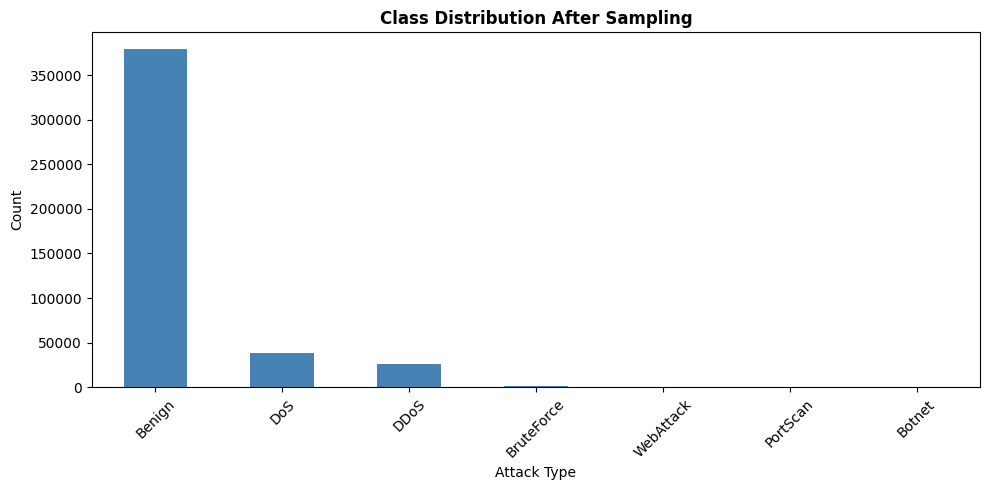

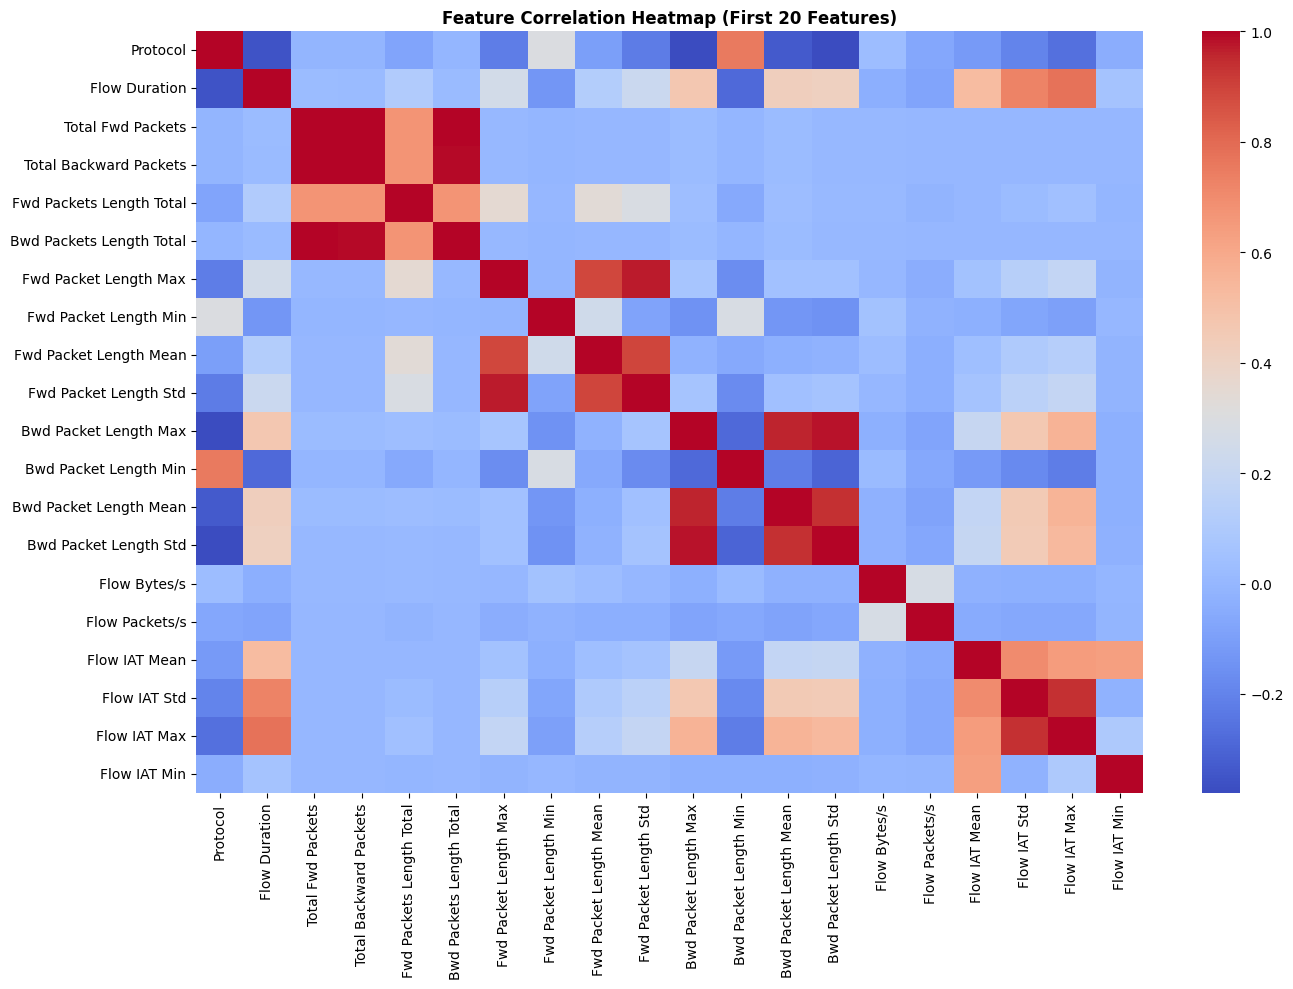

In [41]:
# Class distribution bar chart
df_sampled['Label'].value_counts().plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Class Distribution After Sampling', fontweight='bold')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation heatmap (top 20 features for readability)
plt.figure(figsize=(14, 10))
sns.heatmap(X.iloc[:, :20].corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap (First 20 Features)', fontweight='bold')
plt.tight_layout()
plt.show()

## **SMOTE & Train/Test Split and Standarization**

In [42]:
import sys
!{sys.executable} -m pip install imbalanced-learn

In [43]:
from imblearn.over_sampling import SMOTE

# Define target count as 10% of majority class to avoid over-sampling
target_count = int(303249 * 0.10)

# Only oversample classes below the target count
sampling_strategy = {}
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    if cnt < target_count:
        sampling_strategy[cls] = target_count

# Apply controlled SMOTE on SCALED training data only
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Class distribution after controlled SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f"  {cls}: {cnt}")

print(f"\nX_train shape after SMOTE: {X_train_smote.shape}")

Class distribution after controlled SMOTE:
  Benign: 303249
  Botnet: 30324
  BruteForce: 30324
  DDoS: 30324
  DoS: 30999
  PortScan: 30324
  WebAttack: 30324

X_train shape after SMOTE: (485868, 77)


In [44]:
# The default SMOTE oversamples all minority classes to match the majority class (Benign: 303,249).
# This creates excessive synthetic data (e.g., Botnet: 230 → 303,249),
# which risks the model learning synthetic patterns rather than real ones.
# To avoid this, we limit oversampling to 10% of the majority class (~30,000),
# which balances the dataset without introducing too much artificial data.

# Define target count as 10% of Benign class
target_count = int(303249 * 0.10)
print(f"Target count for minority classes: {target_count}")

# Only oversample classes that are below the target count
sampling_strategy = {}
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    if cnt < target_count:
        sampling_strategy[cls] = target_count

print(f"Sampling strategy: {sampling_strategy}")

# Apply SMOTE with controlled sampling strategy to balance minority classes
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Class distribution after controlled SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f"  {cls}: {cnt}")
print(f"\nX_train shape after SMOTE: {X_train_smote.shape}")

Target count for minority classes: 30324
Sampling strategy: {np.int64(1): 30324, np.int64(2): 30324, np.int64(3): 30324, np.int64(5): 30324, np.int64(6): 30324}
Class distribution after controlled SMOTE:
  Benign: 303249
  Botnet: 30324
  BruteForce: 30324
  DDoS: 30324
  DoS: 30999
  PortScan: 30324
  WebAttack: 30324

X_train shape after SMOTE: (485868, 77)


## Applying Random Forest: First Ensemble model

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

rf = RandomForestClassifier(
    n_estimators=100,        # 100 trees
    max_depth=6,           # limit tree depth to save memory
    max_features='sqrt',    # 9 features per split
    min_samples_leaf=10,    # prune small leaves = smaller trees
    n_jobs=-1,              # use ALL CPU cores in parallel
    random_state=42,
    class_weight='balanced' # handles remaining imbalance without SMOTE overhead
)

rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test_scaled)

=== First Model Metrics ===
Accuracy:  0.9466
Precision: 0.9904
Recall:    0.9466
F1 score:  0.9667

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.94      0.97     75813
      Botnet       0.03      1.00      0.05        57
  BruteForce       0.71      0.98      0.82       366
        DDoS       0.97      1.00      0.98      5121
         DoS       0.97      0.96      0.97      7750
    PortScan       0.10      0.97      0.17        78
   WebAttack       0.06      0.94      0.11        86

    accuracy                           0.95     89271
   macro avg       0.55      0.97      0.58     89271
weighted avg       0.99      0.95      0.97     89271



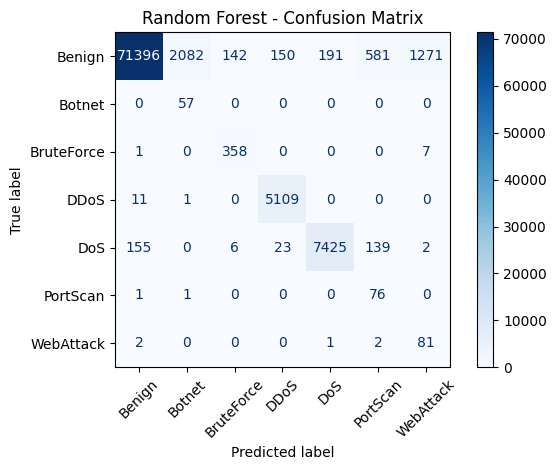

In [46]:
from sklearn.metrics import f1_score, classification_report, roc_auc_score

# performance metrics for first model
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
cm = confusion_matrix(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf, average='weighted')

print('=' * 3 + ' First Model Metrics ' + '=' * 3)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 score:  {f1:.4f}")

# per-class breakdown
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

## Appying XGBoost: Second Model Ensemble

In [47]:
from xgboost import XGBClassifier

# 1. Initialize the XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',
    num_class=len(le.classes_), 
    tree_method='hist', 
    random_state=42,
    n_jobs=-1
)

# 2. Train using the SMOTE-balanced data
xgb_model.fit(X_train_smote, y_train_smote)

# 3. Predict on the original test set
y_pred_xgb = xgb_model.predict(X_test_scaled)

=== XGBoost Model Metrics ===
Accuracy:  0.9977
Precision: 0.9987
Recall:    0.9977
F1 score:  0.9981

Detailed Classification Report (XGBoost):
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     75813
      Botnet       0.30      0.98      0.46        57
  BruteForce       0.99      1.00      1.00       366
        DDoS       1.00      1.00      1.00      5121
         DoS       1.00      1.00      1.00      7750
    PortScan       0.90      0.99      0.94        78
   WebAttack       0.86      0.99      0.92        86

    accuracy                           1.00     89271
   macro avg       0.86      0.99      0.90     89271
weighted avg       1.00      1.00      1.00     89271



<Figure size 1000x800 with 0 Axes>

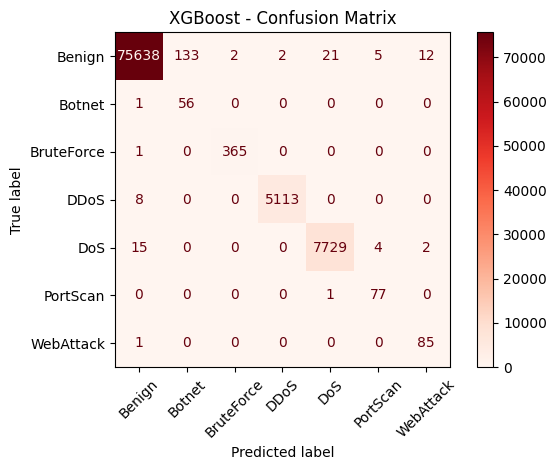

In [48]:
# 1. Calculate performance metrics for XGBoost
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# 2. Print Summary Table
print('=' * 3 + ' XGBoost Model Metrics ' + '=' * 3)
print(f"Accuracy:  {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1 score:  {f1_xgb:.4f}")

# 3. Per-class breakdown
print("\nDetailed Classification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# 4. Confusion Matrix Visualization
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=le.classes_)
disp.plot(cmap='Reds', xticks_rotation=45) 
plt.title("XGBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

In [49]:
from sklearn.preprocessing import label_binarize

# Evaluate Random Forest
print("=" * 40)
print("Random Forest Evaluation")
print("=" * 40)
y_pred_rf = rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

y_prob_rf = rf.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
auc_rf = roc_auc_score(y_test_bin, y_prob_rf, multi_class='ovr', average='weighted')
print(f"AUC-ROC (weighted): {auc_rf:.4f}")

# Evaluate XGBoost
print("=" * 40)
print("XGBoost Evaluation")
print("=" * 40)
y_pred_xgb = xgb_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

y_prob_xgb = xgb_model.predict_proba(X_test_scaled)
auc_xgb = roc_auc_score(y_test_bin, y_prob_xgb, multi_class='ovr', average='weighted')
print(f"AUC-ROC (weighted): {auc_xgb:.4f}")

Random Forest Evaluation
              precision    recall  f1-score   support

      Benign       1.00      0.94      0.97     75813
      Botnet       0.03      1.00      0.05        57
  BruteForce       0.71      0.98      0.82       366
        DDoS       0.97      1.00      0.98      5121
         DoS       0.97      0.96      0.97      7750
    PortScan       0.10      0.97      0.17        78
   WebAttack       0.06      0.94      0.11        86

    accuracy                           0.95     89271
   macro avg       0.55      0.97      0.58     89271
weighted avg       0.99      0.95      0.97     89271

AUC-ROC (weighted): 0.9980
XGBoost Evaluation
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     75813
      Botnet       0.30      0.98      0.46        57
  BruteForce       0.99      1.00      1.00       366
        DDoS       1.00      1.00      1.00      5121
         DoS       1.00      1.00      1.00      7750
    Por

## Prepare test dataset for Demo

In [50]:
import joblib

# Get feature names directly from X_test columns
feature_names = X_test.columns.tolist()

# Save model artifacts
joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

# Save unseen test data (already a DataFrame)
X_test.to_csv('unseen_test_data.csv', index=False)

# Verify all files
for f in ['xgb_model.pkl', 'scaler.pkl', 'label_encoder.pkl',
          'feature_names.pkl', 'unseen_test_data.csv']:
    print(f"{f}: {os.path.getsize(f)/1024:.1f} KB")

xgb_model.pkl: 1503.5 KB
scaler.pkl: 4.0 KB
label_encoder.pkl: 0.5 KB
feature_names.pkl: 1.4 KB
unseen_test_data.csv: 28560.4 KB


In [ ]:
demo_df = X_test.copy()
demo_df['Actual_Label'] = le.inverse_transform(y_test)

# Demo 1. Balanced 
demo1 = demo_df.groupby('Actual_Label').head(10).reset_index(drop=True)
demo1.to_csv('demo_balanced.csv', index=False)
print("Demo 1 - Balanced:")
print(demo1['Actual_Label'].value_counts())

# Demo 2. Attack Heavy 
attack_classes = ['DoS', 'DDoS', 'BruteForce', 'PortScan', 'WebAttack', 'Botnet']
demo2 = demo_df[demo_df['Actual_Label'].isin(attack_classes)].groupby('Actual_Label').head(15).reset_index(drop=True)
demo2.to_csv('demo_attack_heavy.csv', index=False)
print("\nDemo 2 - Attack Heavy:")
print(demo2['Actual_Label'].value_counts())

# Demo 3. Mixed Realistic 
benign_sample = demo_df[demo_df['Actual_Label'] == 'Benign'].head(50)
attack_sample = demo_df[demo_df['Actual_Label'] != 'Benign'].groupby('Actual_Label').head(5)
demo3 = pd.concat([benign_sample, attack_sample]).reset_index(drop=True)
demo3.to_csv('demo_realistic.csv', index=False)
print("\nDemo 3 - Realistic:")
print(demo3['Actual_Label'].value_counts())

Demo 1 - Balanced:
Actual_Label
Benign        10
DoS           10
DDoS          10
WebAttack     10
BruteForce    10
PortScan      10
Botnet        10
Name: count, dtype: int64

Demo 2 - Attack Heavy:
Actual_Label
DoS           15
DDoS          15
WebAttack     15
BruteForce    15
PortScan      15
Botnet        15
Name: count, dtype: int64

Demo 3 - Realistic:
Actual_Label
Benign        50
DoS            5
DDoS           5
WebAttack      5
BruteForce     5
PortScan       5
Botnet         5
Name: count, dtype: int64
